# H2A variant windowed AMPness analysis

Plot per-window P(AMP) and sigma (z) scores along each parent sequence from a windowed comparison run.

**Input** (edit `COMPARISON_CSV` in the first code cell): path relative to `sequence_to_svm_minimal/`, e.g. `data/test/H2A_variants/generated/model_comparison_windowed_latest.csv`. `window_map.csv` is read from `inputs/window_map.csv` next to that file when the comparison CSV lacks `parent_id` / `start` / `length` columns.

**Plots**: (1) line/scatter panels — parents side by side, one row per model; (2) mean-per-residue heatmap bars — same layout. Sigma-score versions use `*_score_z` columns (same layout, symmetric y-axis / color scale).


In [1]:
from __future__ import annotations

import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Path relative to sequence_to_svm_minimal/
# COMPARISON_CSV = "data/test/H2A_variants/generated/model_comparison_windowed_latest.csv"
COMPARISON_CSV = "data/test/H2A_homologues/generated/model_comparison_windowed_latest.csv"

# Base string for figure titles (used by both plot cells below)
# CHART_NAME = "H2A variants"
CHART_NAME = "H2A homologues"

# Models to plot (columns ending with _prob_AMP). None = every model.
PROB_COLUMN_SUBSTR: str | None = None  # e.g. "Geo" to restrict; None = all

# Plotting
FIGWIDTH_PER_PARENT = 3.0
FIGHEIGHT_PER_MODEL = 2.8
HEATMAP_CMAP = "viridis"


def svm_path(rel: str) -> Path:
    rel = rel.lstrip("/\\")
    for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
        root = p / "sequence_to_svm_minimal"
        if root.is_dir():
            path = root / rel
            if not path.is_file():
                raise FileNotFoundError(path)
            return path
    raise FileNotFoundError("sequence_to_svm_minimal not found from current working directory")


comparison_csv = svm_path(COMPARISON_CSV)
window_map_csv = comparison_csv.parent / "inputs/window_map.csv"

print("comparison:", comparison_csv)
print("window_map:", window_map_csv)


comparison: /mnt/c/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction/sequence_to_svm_minimal/data/test/H2A_homologues/generated/model_comparison_windowed_latest.csv
window_map: /mnt/c/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction/sequence_to_svm_minimal/data/test/H2A_homologues/generated/inputs/window_map.csv


In [2]:
SUFFIX = "_prob_AMP"
WINDOW_LAYOUT_COLS = frozenset({"parent_id", "start", "length"})


def pick_prob_columns(cols: list[str], substr: str | None) -> list[str]:
    out = sorted(c for c in cols if c.endswith(SUFFIX))
    if substr:
        out = [c for c in out if substr in c]
    return out


def _normalize_peptide_id(value: object) -> str:
    return str(value).strip().upper()


def _with_center(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["center"] = out["start"].astype(float) + out["length"].astype(float) / 2.0
    return out


def _merge_with_window_map(comp: pd.DataFrame, wmap: pd.DataFrame) -> pd.DataFrame:
    need = {"peptide_id", "parent_id", "start", "length"}
    miss = need - set(wmap.columns)
    if miss:
        raise ValueError(f"window_map.csv missing columns: {sorted(miss)}")

    extra = [c for c in ("window_id", "seqIndex") if c in wmap.columns]
    w_sub = wmap[list(need | set(extra))].copy()

    for on in ("peptide_id",):
        df = comp.merge(w_sub, on=on, how="inner", suffixes=("", "_map"))
        if not df.empty:
            return df

    comp_n = comp.copy()
    comp_n["_pid_norm"] = comp_n["peptide_id"].map(_normalize_peptide_id)
    w_n = w_sub.copy()
    w_n["_pid_norm"] = w_n["peptide_id"].map(_normalize_peptide_id)
    drop = [c for c in w_n.columns if c in comp_n.columns and c != "_pid_norm"]
    df = comp_n.merge(w_n.drop(columns=drop, errors="ignore"), on="_pid_norm", how="inner")
    if not df.empty:
        return df.drop(columns=["_pid_norm"], errors="ignore")

    if "seqIndex" in comp.columns and "seqIndex" in w_sub.columns:
        idx_cols = ["seqIndex", "parent_id", "start", "length", *extra]
        df = comp.merge(w_sub[idx_cols].drop_duplicates("seqIndex"), on="seqIndex", how="inner")
        if not df.empty:
            return df

    raise ValueError(
        "Merge produced 0 rows: check peptide_id / seqIndex alignment between comparison CSV and window_map."
    )


def load_merged(comparison_csv: Path, window_map_csv: Path | None = None) -> pd.DataFrame:
    """Load per-window predictions with parent layout columns for plotting."""
    if not comparison_csv.is_file():
        raise FileNotFoundError(f"comparison CSV not found: {comparison_csv}")

    comp = pd.read_csv(comparison_csv)
    if WINDOW_LAYOUT_COLS.issubset(comp.columns):
        df = comp.copy()
        if "window_id" not in df.columns and window_map_csv and window_map_csv.is_file():
            wmap = pd.read_csv(window_map_csv)
            keys = [c for c in ("peptide_id", "seqIndex") if c in df.columns and c in wmap.columns]
            if keys:
                extra = [c for c in ("window_id",) if c in wmap.columns]
                df = df.merge(wmap[keys + extra].drop_duplicates(keys[0]), on=keys[0], how="left")
        return _with_center(df)

    if window_map_csv is None or not window_map_csv.is_file():
        raise FileNotFoundError(
            f"Comparison CSV has no parent_id/start/length columns and window_map missing: {window_map_csv}"
        )
    wmap = pd.read_csv(window_map_csv)
    return _with_center(_merge_with_window_map(comp, wmap))


def load_windowed_sequence_df(comparison_csv: Path) -> pd.DataFrame:
    """Alias for windowed exports from compare_model_predictions_windowed.py."""
    return load_merged(comparison_csv, window_map_csv=None)


def mean_prob_along_parent(parent_df: pd.DataFrame, prob_col: str, parent_len: int) -> np.ndarray:
    pos_sum = np.zeros(parent_len, dtype=np.float64)
    pos_count = np.zeros(parent_len, dtype=np.float64)
    for _, r in parent_df.iterrows():
        s = int(r["start"])
        L = int(r["length"])
        v = float(r[prob_col])
        if not math.isfinite(v):
            continue
        lo, hi = max(0, s), min(parent_len, s + L)
        if lo < hi:
            pos_sum[lo:hi] += v
            pos_count[lo:hi] += 1.0
    out = np.full(parent_len, np.nan, dtype=np.float64)
    covered = pos_count > 0
    out[covered] = pos_sum[covered] / pos_count[covered]
    return out


def max_prob_along_parent(parent_df: pd.DataFrame, prob_col: str, parent_len: int) -> np.ndarray:
    pos = np.zeros(parent_len, dtype=np.float64)
    covered = np.zeros(parent_len, dtype=bool)
    for _, r in parent_df.iterrows():
        s = int(r["start"])
        L = int(r["length"])
        v = float(r[prob_col])
        if not math.isfinite(v):
            continue
        lo, hi = max(0, s), min(parent_len, s + L)
        if lo < hi:
            pos[lo:hi] = np.maximum(pos[lo:hi], v)
            covered[lo:hi] = True
    out = np.full(parent_len, np.nan, dtype=np.float64)
    out[covered] = pos[covered]
    return out


def _draw_residue_histogram(
    ax,
    x_idx: np.ndarray,
    profile: np.ndarray,
    parent_len: int,
    cmap,
    norm,
) -> None:
    heights = np.where(np.isfinite(profile), profile, 0.0)
    bar_colors = [
        cmap(norm(v)) if np.isfinite(v) else (0.85, 0.85, 0.85, 1.0)
        for v in profile
    ]
    ax.bar(
        x_idx,
        heights,
        width=1.0,
        color=bar_colors,
        align="edge",
        linewidth=0,
        edgecolor="none",
    )
    ax.set_xlim(0, parent_len)
    ax.set_ylim(0, 1)


def plot_ampness_panels(
    df: pd.DataFrame,
    prob_cols: list[str],
    *,
    max_parents: int | None = 12,
    figwidth_per_model: float = 4.0,
    figheight_per_parent: float = 3.0,
    heatmap_cmap: str = "viridis",
    main_title: str = "",
    subtitle: str = "",  # unused; kept for backward compatibility with callers
) -> None:
    """Print three figures: line/scatter, mean-per-residue bars, max-per-residue bars."""
    parents = sorted(df["parent_id"].astype(str).unique())
    if max_parents is not None:
        parents = parents[:max_parents]
    if not parents:
        print("No parent_id values to plot.")
        return
    if not prob_cols:
        print("No probability columns to plot.")
        return

    prob_cols = list(reversed(prob_cols))
    n_p, n_m = len(parents), len(prob_cols)
    fig_w = max(6.0, figwidth_per_model * n_m)
    fig_h = max(3.5, figheight_per_parent * n_p)
    cmap = plt.get_cmap(heatmap_cmap)
    norm = plt.Normalize(vmin=0.0, vmax=1.0)

    fig_line, axes_line = plt.subplots(
        n_p,
        n_m,
        figsize=(fig_w, fig_h),
        sharex="col",
        sharey="row",
        squeeze=False,
        layout="constrained",
    )
    axes_line = np.atleast_2d(np.asarray(axes_line, dtype=object))

    fig_bar, axes_bar = plt.subplots(
        n_p,
        n_m,
        figsize=(fig_w, fig_h),
        sharex="col",
        sharey="row",
        squeeze=False,
        layout="constrained",
    )
    axes_bar = np.atleast_2d(np.asarray(axes_bar, dtype=object))

    fig_max, axes_max = plt.subplots(
        n_p,
        n_m,
        figsize=(fig_w, fig_h),
        sharex="col",
        sharey="row",
        squeeze=False,
        layout="constrained",
    )
    axes_max = np.atleast_2d(np.asarray(axes_max, dtype=object))

    for i, pid in enumerate(parents):
        sub = df[df["parent_id"].astype(str) == pid].sort_values(["start", "length"])
        parent_len = int((sub["start"] + sub["length"]).max())
        x_idx = np.arange(parent_len)

        for j, pc in enumerate(prob_cols):
            label = pc[: -len(SUFFIX)]
            color = f"C{j}"
            profile_mean = mean_prob_along_parent(sub, pc, parent_len)
            profile_max = max_prob_along_parent(sub, pc, parent_len)

            ax_line = axes_line[i, j]
            ax_line.scatter(sub["center"], sub[pc], s=10, alpha=0.4, color=color)
            ax_line.plot(x_idx, profile_mean, linewidth=1.6, alpha=0.95, color=color)
            ax_line.set_ylim(-0.02, 1.02)
            ax_line.set_xlim(0, parent_len)
            if i == 0:
                ax_line.set_title(label)
            if j == 0:
                ax_line.set_ylabel("P(AMP)")
            if j == n_m - 1:
                ax2 = ax_line.twinx()
                ax2.set_ylabel(pid, rotation=270, labelpad=14)
                ax2.set_yticks([])
            if i == n_p - 1:
                ax_line.set_xlabel("Residue index (0-based)")

            ax_bar = axes_bar[i, j]
            _draw_residue_histogram(ax_bar, x_idx, profile_mean, parent_len, cmap, norm)
            if i == 0:
                ax_bar.set_title(label)
            if j == 0:
                ax_bar.set_ylabel("P(AMP)")
            if j == n_m - 1:
                ax2 = ax_bar.twinx()
                ax2.set_ylabel(pid, rotation=270, labelpad=14)
                ax2.set_yticks([])
            if i == n_p - 1:
                ax_bar.set_xlabel("Residue index (0-based)")
                sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
                sm.set_array([])
                fig_bar.colorbar(sm, ax=ax_bar, fraction=0.046, pad=0.04, label="P(AMP)")

            ax_max = axes_max[i, j]
            _draw_residue_histogram(ax_max, x_idx, profile_max, parent_len, cmap, norm)
            if i == 0:
                ax_max.set_title(label)
            if j == 0:
                ax_max.set_ylabel("P(AMP)")
            if j == n_m - 1:
                ax2 = ax_max.twinx()
                ax2.set_ylabel(pid, rotation=270, labelpad=14)
                ax2.set_yticks([])
            if i == n_p - 1:
                ax_max.set_xlabel("Residue index (0-based)")
                sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
                sm.set_array([])
                fig_max.colorbar(sm, ax=ax_max, fraction=0.046, pad=0.04, label="P(AMP)")

    if main_title:
        fig_line.suptitle(main_title)
        fig_bar.suptitle(f"{main_title} — mean per residue")
        fig_max.suptitle(f"{main_title} — max per residue")
    plt.show()
    plt.show()
    plt.show()



def plot_windowed_predictions_per_parent(
    df: pd.DataFrame,
    prob_cols: list[str],
    *,
    figwidth_per_parent: float = 3.0,
    figheight_per_model: float = 2.8,
    main_title: str = "",
) -> None:
    """One figure — parents side by side, one row per model."""
    parents = sorted(df["parent_id"].astype(str).unique())
    if not parents:
        print("No parent_id values to plot.")
        return
    if not prob_cols:
        print("No probability columns to plot.")
        return

    prob_cols = list(reversed(prob_cols))
    n_m, n_p = len(prob_cols), len(parents)
    fig_w = max(6.0, figwidth_per_parent * n_p)
    fig_h = max(3.0, figheight_per_model * n_m)

    fig, axes = plt.subplots(
        n_m,
        n_p,
        figsize=(fig_w, fig_h),
        sharex=True,
        sharey=True,
        squeeze=False,
        layout="constrained",
    )
    axes = np.atleast_2d(np.asarray(axes, dtype=object))

    for j, pid in enumerate(parents):
        sub = df[df["parent_id"].astype(str) == pid].sort_values(["start", "length"])
        parent_len = int((sub["start"] + sub["length"]).max())
        x_idx = np.arange(parent_len)

        for i, pc in enumerate(prob_cols):
            label = pc[: -len(SUFFIX)]
            color = f"C{i}"
            profile_mean = mean_prob_along_parent(sub, pc, parent_len)
            ax = axes[i, j]
            ax.scatter(sub["center"], sub[pc], s=8, alpha=0.4, color=color)
            ax.plot(x_idx, profile_mean, linewidth=1.5, alpha=0.95, color=color)
            ax.set_ylim(-0.02, 1.02)
            ax.set_xlim(0, parent_len)
            if i == 0:
                ax.set_title(pid, fontsize=10)
            if j == 0:
                ax.set_ylabel(f"{label}\nP(AMP)", fontsize=9)
            if i == n_m - 1:
                ax.set_xlabel("Position")

    if main_title:
        fig.suptitle(main_title, fontsize=12)
    plt.show()


def plot_overlaid_mean_prob_per_parent(
    df: pd.DataFrame,
    prob_cols: list[str],
    *,
    main_title: str = "",
    figwidth: float = 9.0,
    figheight_per_model: float = 4.0,
    style: str = "bars",
    fill_alpha: float = 0.38,
    line_alpha: float = 0.85,
    outline_profiles: bool = True,
) -> None:
    """Overlay mean P(AMP) profiles for every parent on a single axes per model."""
    parents = sorted(df["parent_id"].astype(str).unique())
    if not parents:
        print("No parent_id values to plot.")
        return
    if not prob_cols:
        print("No probability columns to plot.")
        return
    if style not in {"bars", "area", "lines"}:
        raise ValueError(f"style must be 'bars', 'area', or 'lines', got {style!r}")

    prob_cols = list(reversed(prob_cols))
    n_m = len(prob_cols)
    fig, axes = plt.subplots(
        n_m,
        1,
        figsize=(figwidth, max(3.5, figheight_per_model * n_m)),
        squeeze=False,
        sharex=False,
        sharey=True,
        layout="constrained",
    )
    axes = np.atleast_2d(np.asarray(axes, dtype=object))

    for i, pc in enumerate(prob_cols):
        label = pc[: -len(SUFFIX)]
        ax = axes[i, 0]
        max_len = 0
        for j, pid in enumerate(parents):
            sub = df[df["parent_id"].astype(str) == pid].sort_values(["start", "length"])
            parent_len = int((sub["start"] + sub["length"]).max())
            max_len = max(max_len, parent_len)
            x_idx = np.arange(parent_len)
            profile_mean = mean_prob_along_parent(sub, pc, parent_len)
            heights = np.where(np.isfinite(profile_mean), profile_mean, 0.0)
            color = f"C{j % 10}"

            if style == "bars":
                ax.bar(
                    x_idx,
                    heights,
                    width=1.0,
                    color=color,
                    alpha=fill_alpha,
                    align="edge",
                    linewidth=0,
                    edgecolor="none",
                    label=pid,
                )
            elif style == "area":
                ax.fill_between(
                    x_idx,
                    0.0,
                    heights,
                    color=color,
                    alpha=fill_alpha,
                    linewidth=0,
                    label=pid,
                )
            else:
                ax.plot(x_idx, profile_mean, linewidth=1.5, alpha=line_alpha, label=pid, color=color)

            if outline_profiles and style in {"bars", "area"}:
                ax.plot(
                    x_idx,
                    profile_mean,
                    linewidth=0.9,
                    alpha=min(1.0, fill_alpha + 0.45),
                    color=color,
                )

        ax.set_ylim(-0.02, 1.02)
        ax.set_xlim(0, max_len)
        ax.set_ylabel(f"{label}\nP(AMP)", fontsize=9)
        ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
        if i == n_m - 1:
            ax.set_xlabel("Residue index (0-based)")

    style_label = {"bars": "overlapping bars", "area": "overlapping fills", "lines": "overlaid lines"}[style]
    if main_title:
        fig.suptitle(f"{main_title} — {style_label} mean P(AMP)", fontsize=12)
    plt.show()


def mean_prob_across_parents(
    df: pd.DataFrame,
    prob_col: str,
    parents: list[str] | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    """Average per-parent mean P(AMP) profiles position-wise (nan-mean across parents)."""
    if parents is None:
        parents = sorted(df["parent_id"].astype(str).unique())
    profiles: list[np.ndarray] = []
    max_len = 0
    for pid in parents:
        sub = df[df["parent_id"].astype(str) == pid].sort_values(["start", "length"])
        parent_len = int((sub["start"] + sub["length"]).max())
        max_len = max(max_len, parent_len)
        profiles.append(mean_prob_along_parent(sub, prob_col, parent_len))
    if not profiles:
        return np.array([], dtype=np.float64), np.array([], dtype=np.float64)

    stacked = np.full((len(profiles), max_len), np.nan, dtype=np.float64)
    for i, profile in enumerate(profiles):
        stacked[i, : len(profile)] = profile
    avg = np.nanmean(stacked, axis=0)
    return np.arange(max_len), avg


def plot_averaged_mean_prob_across_parents(
    df: pd.DataFrame,
    prob_cols: list[str],
    *,
    main_title: str = "",
    figwidth: float = 9.0,
    figheight_per_model: float = 4.0,
    line_color: str = "C0",
) -> None:
    """Plot one line per model: mean P(AMP) averaged across all parents."""
    parents = sorted(df["parent_id"].astype(str).unique())
    if not parents:
        print("No parent_id values to plot.")
        return
    if not prob_cols:
        print("No probability columns to plot.")
        return

    prob_cols = list(reversed(prob_cols))
    n_m = len(prob_cols)
    fig, axes = plt.subplots(
        n_m,
        1,
        figsize=(figwidth, max(3.5, figheight_per_model * n_m)),
        squeeze=False,
        sharex=True,
        sharey=True,
        layout="constrained",
    )
    axes = np.atleast_2d(np.asarray(axes, dtype=object))
    max_len = 0

    for i, pc in enumerate(prob_cols):
        label = pc[: -len(SUFFIX)]
        x_idx, avg_profile = mean_prob_across_parents(df, pc, parents)
        max_len = max(max_len, len(x_idx))
        ax = axes[i, 0]
        ax.plot(x_idx, avg_profile, linewidth=2.0, alpha=0.95, color=line_color)
        ax.set_ylim(-0.02, 1.02)
        ax.set_ylabel(f"{label}\nP(AMP)", fontsize=9)
        if i == n_m - 1:
            ax.set_xlabel("Residue index (0-based)")

    axes[0, 0].set_xlim(0, max_len)
    if main_title:
        fig.suptitle(
            f"{main_title} — mean P(AMP) averaged across {len(parents)} parents",
            fontsize=12,
        )
    plt.show()


def plot_mean_heatmap_panels(
    df: pd.DataFrame,
    prob_cols: list[str],
    *,
    figwidth_per_parent: float = 3.0,
    figheight_per_model: float = 2.8,
    heatmap_cmap: str = "viridis",
    main_title: str = "",
) -> None:
    """One figure — mean-per-residue heatmap bars, parents side by side."""
    parents = sorted(df["parent_id"].astype(str).unique())
    if not parents:
        print("No parent_id values to plot.")
        return
    if not prob_cols:
        print("No probability columns to plot.")
        return

    prob_cols = list(reversed(prob_cols))
    n_m, n_p = len(prob_cols), len(parents)
    fig_w = max(6.0, figwidth_per_parent * n_p)
    fig_h = max(3.0, figheight_per_model * n_m)
    cmap = plt.get_cmap(heatmap_cmap)
    norm = plt.Normalize(vmin=0.0, vmax=1.0)

    fig, axes = plt.subplots(
        n_m,
        n_p,
        figsize=(fig_w, fig_h),
        sharex=True,
        sharey=True,
        squeeze=False,
        layout="constrained",
    )
    axes = np.atleast_2d(np.asarray(axes, dtype=object))

    for j, pid in enumerate(parents):
        sub = df[df["parent_id"].astype(str) == pid].sort_values(["start", "length"])
        parent_len = int((sub["start"] + sub["length"]).max())
        x_idx = np.arange(parent_len)

        for i, pc in enumerate(prob_cols):
            label = pc[: -len(SUFFIX)]
            profile_mean = mean_prob_along_parent(sub, pc, parent_len)
            ax = axes[i, j]
            _draw_residue_histogram(ax, x_idx, profile_mean, parent_len, cmap, norm)
            if i == 0:
                ax.set_title(pid, fontsize=10)
            if j == 0:
                ax.set_ylabel(f"{label}\nP(AMP)", fontsize=9)
            if i == n_m - 1:
                ax.set_xlabel("Position")

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=axes, shrink=0.85, label="P(AMP)")
    if main_title:
        fig.suptitle(f"{main_title} — mean", fontsize=12)
    plt.show()


SCORE_SUFFIX = "_score_z"


def pick_score_columns(cols: list[str], substr: str | None) -> list[str]:
    out = sorted(c for c in cols if c.endswith(SCORE_SUFFIX))
    if substr:
        out = [c for c in out if substr in c]
    return out


def max_score_along_parent(parent_df: pd.DataFrame, score_col: str, parent_len: int) -> np.ndarray:
    pos = np.full(parent_len, -np.inf, dtype=np.float64)
    covered = np.zeros(parent_len, dtype=bool)
    for _, r in parent_df.iterrows():
        s = int(r["start"])
        L = int(r["length"])
        v = float(r[score_col])
        if not math.isfinite(v):
            continue
        lo, hi = max(0, s), min(parent_len, s + L)
        if lo < hi:
            pos[lo:hi] = np.maximum(pos[lo:hi], v)
            covered[lo:hi] = True
    out = np.full(parent_len, np.nan, dtype=np.float64)
    out[covered] = pos[covered]
    return out


def _sigma_norm(df: pd.DataFrame, score_cols: list[str]) -> plt.Normalize:
    all_vals = df[score_cols].values.flatten()
    all_vals = all_vals[np.isfinite(all_vals)]
    if len(all_vals) > 0:
        abs_max = max(abs(float(all_vals.min())), abs(float(all_vals.max())))
        if abs_max == 0:
            abs_max = 1.0
        return plt.Normalize(vmin=-abs_max, vmax=abs_max)
    return plt.Normalize(vmin=-3.0, vmax=3.0)


def _sigma_ylim(df: pd.DataFrame, score_cols: list[str]) -> tuple[float, float]:
    all_vals = df[score_cols].values.flatten()
    all_vals = all_vals[np.isfinite(all_vals)]
    if len(all_vals) > 0:
        abs_max = max(abs(float(all_vals.min())), abs(float(all_vals.max())))
        padding = abs_max * 0.1 if abs_max > 0 else 0.5
        return (-abs_max - padding, abs_max + padding)
    return (-3.5, 3.5)


def _draw_residue_score_histogram(
    ax,
    x_idx: np.ndarray,
    profile: np.ndarray,
    parent_len: int,
    cmap,
    norm,
    *,
    ylim: tuple[float, float] | None = None,
) -> None:
    heights = np.where(np.isfinite(profile), profile, 0.0)
    bar_colors = [
        cmap(norm(v)) if np.isfinite(v) else (0.85, 0.85, 0.85, 1.0)
        for v in profile
    ]
    ax.bar(
        x_idx,
        heights,
        width=1.0,
        color=bar_colors,
        align="edge",
        linewidth=0,
        edgecolor="none",
    )
    ax.set_xlim(0, parent_len)
    if ylim is not None:
        ax.set_ylim(*ylim)
    else:
        valid_heights = heights[np.isfinite(profile)]
        if len(valid_heights) > 0:
            min_h, max_h = float(valid_heights.min()), float(valid_heights.max())
            padding = (max_h - min_h) * 0.1 if max_h > min_h else 0.5
            ax.set_ylim(min_h - padding, max_h + padding)
        else:
            ax.set_ylim(-3, 3)


def plot_windowed_sigma_per_parent(
    df: pd.DataFrame,
    score_cols: list[str],
    *,
    figwidth_per_parent: float = 3.0,
    figheight_per_model: float = 2.8,
    main_title: str = "",
) -> None:
    """One figure — parents side by side, one row per model (sigma / z-score)."""
    parents = sorted(df["parent_id"].astype(str).unique())
    if not parents:
        print("No parent_id values to plot.")
        return
    if not score_cols:
        print("No score columns to plot.")
        return

    score_cols = list(reversed(score_cols))
    n_m, n_p = len(score_cols), len(parents)
    fig_w = max(6.0, figwidth_per_parent * n_p)
    fig_h = max(3.0, figheight_per_model * n_m)
    ylo, yhi = _sigma_ylim(df, score_cols)

    fig, axes = plt.subplots(
        n_m,
        n_p,
        figsize=(fig_w, fig_h),
        sharex=True,
        sharey=True,
        squeeze=False,
        layout="constrained",
    )
    axes = np.atleast_2d(np.asarray(axes, dtype=object))

    for j, pid in enumerate(parents):
        sub = df[df["parent_id"].astype(str) == pid].sort_values(["start", "length"])
        parent_len = int((sub["start"] + sub["length"]).max())
        x_idx = np.arange(parent_len)

        for i, sc in enumerate(score_cols):
            label = sc[: -len(SCORE_SUFFIX)] if sc.endswith(SCORE_SUFFIX) else sc
            color = f"C{i}"
            profile_mean = mean_prob_along_parent(sub, sc, parent_len)
            ax = axes[i, j]
            ax.scatter(sub["center"], sub[sc], s=8, alpha=0.8, color=color)
            ax.plot(x_idx, profile_mean, linewidth=1.5, alpha=0.95, color=color)
            ax.set_ylim(ylo, yhi)
            ax.set_xlim(0, parent_len)
            if i == 0:
                ax.set_title(pid, fontsize=10)
            if j == 0:
                ax.set_ylabel(f"{label}\nSigma score", fontsize=9)
            if i == n_m - 1:
                ax.set_xlabel("Position")

    if main_title:
        fig.suptitle(f"{main_title} — sigma score", fontsize=12)
    plt.show()


def plot_mean_sigma_heatmap_panels(
    df: pd.DataFrame,
    score_cols: list[str],
    *,
    figwidth_per_parent: float = 3.0,
    figheight_per_model: float = 2.8,
    heatmap_cmap: str = "viridis",
    main_title: str = "",
) -> None:
    """One figure — mean-per-residue heatmap bars for sigma scores, parents side by side."""
    parents = sorted(df["parent_id"].astype(str).unique())
    if not parents:
        print("No parent_id values to plot.")
        return
    if not score_cols:
        print("No score columns to plot.")
        return

    score_cols = list(reversed(score_cols))
    n_m, n_p = len(score_cols), len(parents)
    fig_w = max(6.0, figwidth_per_parent * n_p)
    fig_h = max(3.0, figheight_per_model * n_m)
    cmap = plt.get_cmap(heatmap_cmap)
    norm = _sigma_norm(df, score_cols)
    ylo, yhi = _sigma_ylim(df, score_cols)

    fig, axes = plt.subplots(
        n_m,
        n_p,
        figsize=(fig_w, fig_h),
        sharex=True,
        sharey=True,
        squeeze=False,
        layout="constrained",
    )
    axes = np.atleast_2d(np.asarray(axes, dtype=object))

    for j, pid in enumerate(parents):
        sub = df[df["parent_id"].astype(str) == pid].sort_values(["start", "length"])
        parent_len = int((sub["start"] + sub["length"]).max())
        x_idx = np.arange(parent_len)

        for i, sc in enumerate(score_cols):
            label = sc[: -len(SCORE_SUFFIX)] if sc.endswith(SCORE_SUFFIX) else sc
            profile_mean = mean_prob_along_parent(sub, sc, parent_len)
            ax = axes[i, j]
            _draw_residue_score_histogram(
                ax, x_idx, profile_mean, parent_len, cmap, norm, ylim=(ylo, yhi)
            )
            if i == 0:
                ax.set_title(pid, fontsize=10)
            if j == 0:
                ax.set_ylabel(f"{label}\nSigma score", fontsize=9)
            if i == n_m - 1:
                ax.set_xlabel("Position")

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=axes, shrink=0.85, label="Sigma score")
    if main_title:
        fig.suptitle(f"{main_title} — sigma mean", fontsize=12)
    plt.show()


merged rows: 8264
parents: 5 -> ['African Clawed Toad', 'Fission Yeast', 'Human', 'Mouse', 'Rainbow Trout']
plotting models: ['SVM_prob_AMP']


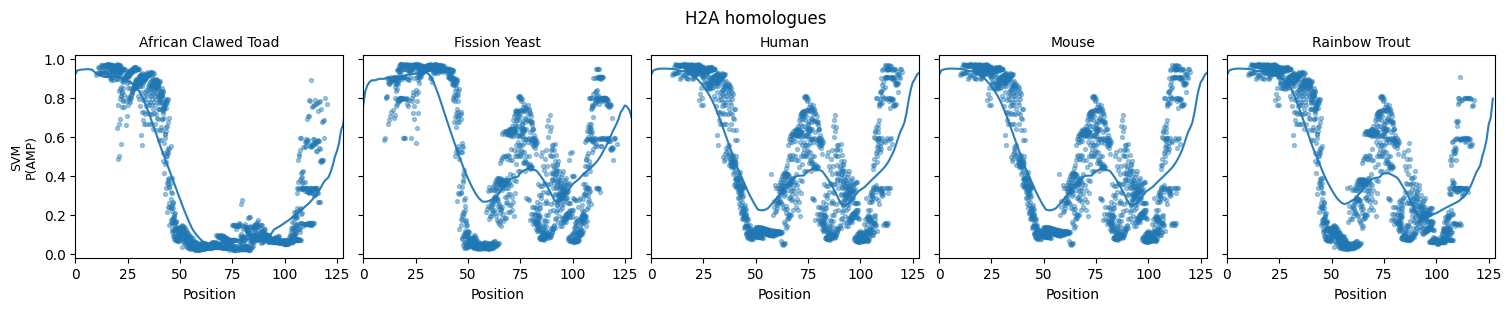

In [3]:
df = load_merged(comparison_csv, window_map_csv)
prob_cols = pick_prob_columns(list(df.columns), PROB_COLUMN_SUBSTR)
if not prob_cols:
    raise ValueError(f"No prob columns matching suffix {SUFFIX!r} and substr={PROB_COLUMN_SUBSTR!r}")

for pc in prob_cols:
    n_finite = int(pd.to_numeric(df[pc], errors="coerce").notna().sum())
    if n_finite == 0:
        print(f"Warning: {pc} has no scores — re-run compare_model_predictions_windowed.py.")

parents = sorted(df["parent_id"].astype(str).unique())
print("merged rows:", len(df))
print("parents:", len(parents), "->", parents)
print("plotting models:", prob_cols)

plot_windowed_predictions_per_parent(
    df,
    prob_cols,
    figwidth_per_parent=FIGWIDTH_PER_PARENT,
    figheight_per_model=FIGHEIGHT_PER_MODEL,
    main_title=CHART_NAME,
)


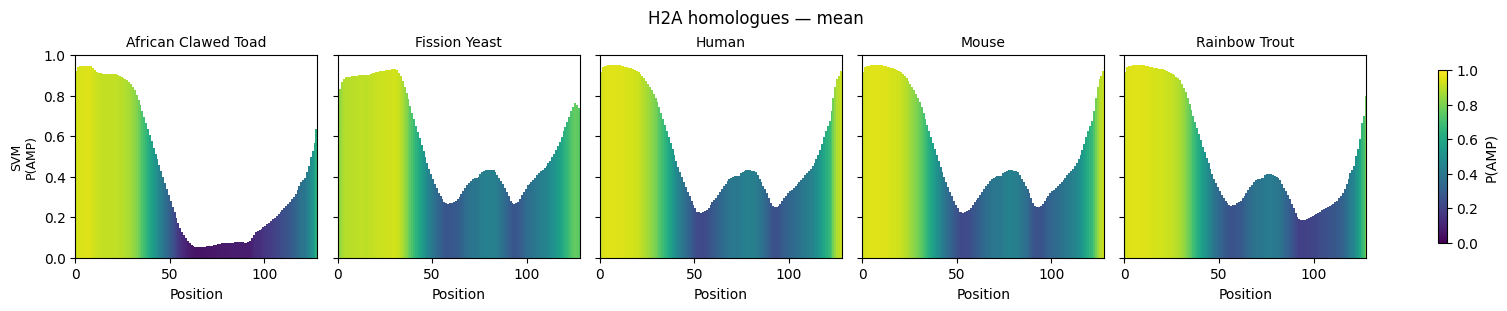

In [4]:
plot_mean_heatmap_panels(
    df,
    prob_cols,
    figwidth_per_parent=FIGWIDTH_PER_PARENT,
    figheight_per_model=FIGHEIGHT_PER_MODEL,
    heatmap_cmap=HEATMAP_CMAP,
    main_title=CHART_NAME,
)

## Sigma score (z-score)

Same layout as the P(AMP) plots above, using `*_score_z` columns from the comparison CSV (see `window_exploration.ipynb`).

plotting sigma models: ['SVM_score_z']


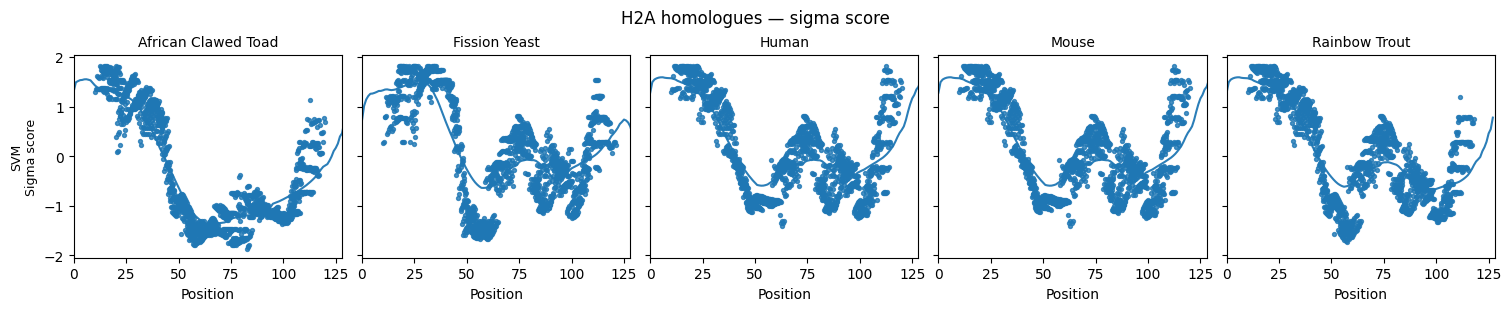

In [5]:
score_cols = pick_score_columns(list(df.columns), PROB_COLUMN_SUBSTR)
if not score_cols:
    raise ValueError(f"No score columns matching suffix {SCORE_SUFFIX!r} and substr={PROB_COLUMN_SUBSTR!r}")

for sc in score_cols:
    n_finite = int(pd.to_numeric(df[sc], errors="coerce").notna().sum())
    if n_finite == 0:
        print(f"Warning: {sc} has no scores — re-run compare_model_predictions_windowed.py.")

print("plotting sigma models:", score_cols)

plot_windowed_sigma_per_parent(
    df,
    score_cols,
    figwidth_per_parent=FIGWIDTH_PER_PARENT,
    figheight_per_model=FIGHEIGHT_PER_MODEL,
    main_title=CHART_NAME,
)

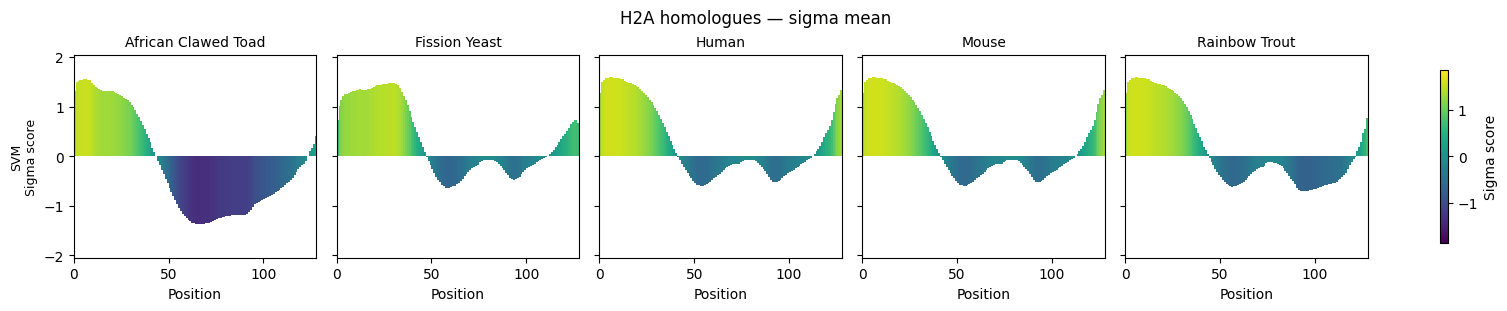

In [6]:
plot_mean_sigma_heatmap_panels(
    df,
    score_cols,
    figwidth_per_parent=FIGWIDTH_PER_PARENT,
    figheight_per_model=FIGHEIGHT_PER_MODEL,
    heatmap_cmap=HEATMAP_CMAP,
    main_title=CHART_NAME,
)

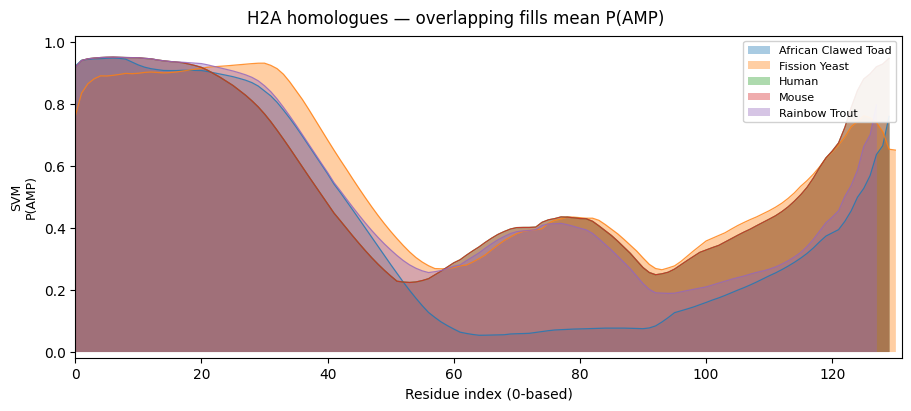

In [9]:
# All parents overlaid on one plot — semi-transparent filled bars per peptide
plot_overlaid_mean_prob_per_parent(
    df,
    prob_cols,
    main_title=CHART_NAME,
    style="area",       # try "area" or "lines"
    fill_alpha=0.38,    # lower = more see-through overlap
    outline_profiles=True,
)
